# **Machine Learning and Model Explainability for Maternal Health Risk Prediction**

**STUDENT: GORATA TLOTLO STONE**

**MODULE: CET313 - ARTIFICIAL INTELLIGENCE**


This notebook implements a prototype machine learning system for predicting maternal health risk levels (low, medium, high) from routine vital signs

In [ ]:
## Install packages
!pip install xgboost shap seaborn

Imports and Global Configuration

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from typing import Dict, Any

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    recall_score,
    make_scorer,
)

import shap

# Plot styling
plt.rcParams["figure.figsize"] = (8, 5)
sns.set(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported; random seed set.")

Libraries imported; random seed set.


Load and Validate the Maternal Health Risk Dataset

In [ ]:
DATA_PATH = "/Maternal Health Risk Data Set.csv"  # adjust if needed

# Load dataset
df_raw = pd.read_csv(DATA_PATH)

print("Raw data preview:")
display(df_raw.head())

print("\nDataset info:")
df_raw.info()

print("\nSummary statistics:")
display(df_raw.describe(include="all"))

# Standardise risk level text (defensive cleaning)
df = df_raw.copy()
df["RiskLevel"] = df["RiskLevel"].astype(str).str.lower().str.strip()

print("\nUnique RiskLevel values after cleaning:")
print(df["RiskLevel"].value_counts())

# Map textual labels to numeric classes
label_mapping = {
    "low risk": 0,
    "low": 0,
    "mid risk": 1,
    "medium risk": 1,
    "mid": 1,
    "medium": 1,
    "high risk": 2,
    "high": 2,
}

df["RiskLabel"] = df["RiskLevel"].map(label_mapping)

# Check for unmapped labels
if df["RiskLabel"].isna().any():
    print("\nWARNING: some RiskLevel values could not be mapped. Inspect these values:")
    display(df[df["RiskLabel"].isna()]["RiskLevel"].value_counts())
    raise ValueError("Unmapped RiskLevel values – extend label_mapping accordingly.")

print("\nNumeric label distribution (0=Low, 1=Medium, 2=High):")
print(df["RiskLabel"].value_counts())

# Missingness check
print("\nMissing values per column:")
print(df.isnull().sum())

# This dataset is usually clean; simple, transparent strategy:
df = df.dropna().reset_index(drop=True)
print("\nShape after dropping any missing rows:", df.shape)

Raw data preview:


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB

Summary statistics:


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014
unique,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,low risk
freq,NaN,NaN,NaN,NaN,NaN,NaN,406
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775,NaN
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702,NaN
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000,NaN
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000,NaN
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000,NaN
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000,NaN



Unique RiskLevel values after cleaning:
RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

Numeric label distribution (0=Low, 1=Medium, 2=High):
RiskLabel
0    406
1    336
2    272
Name: count, dtype: int64

Missing values per column:
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
RiskLabel      0
dtype: int64

Shape after dropping any missing rows: (1014, 8)


Exploratory Data Analysis

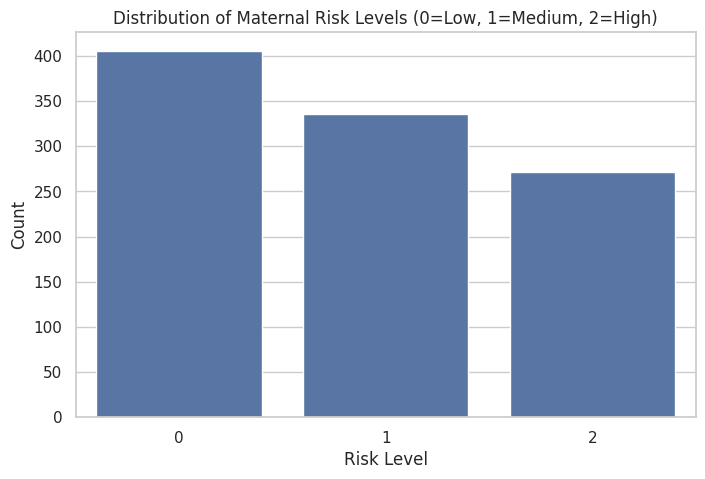

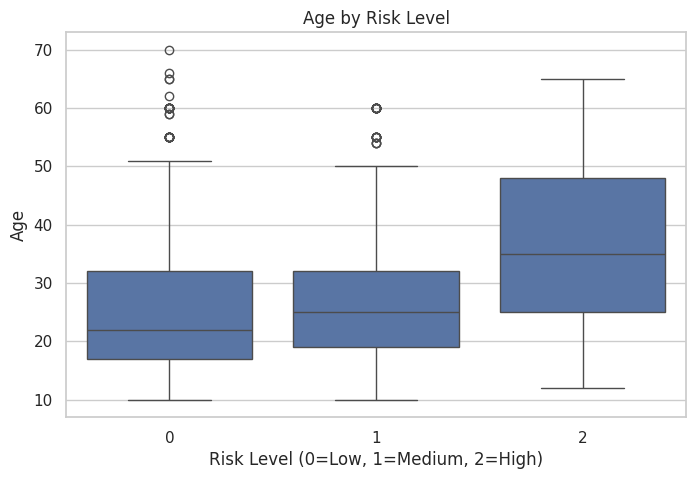

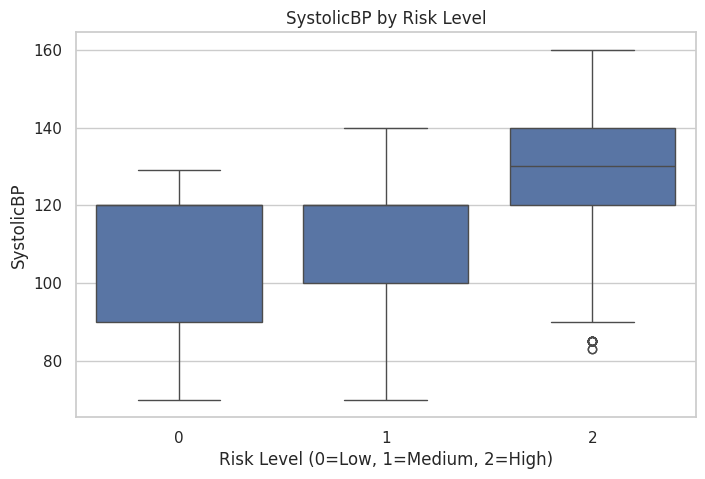

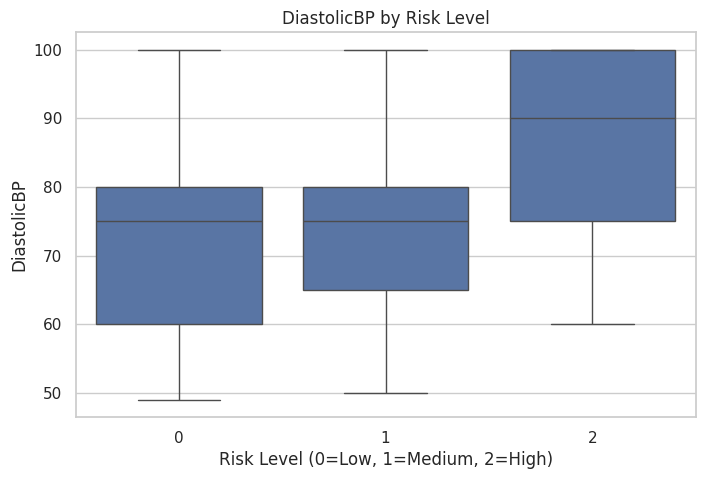

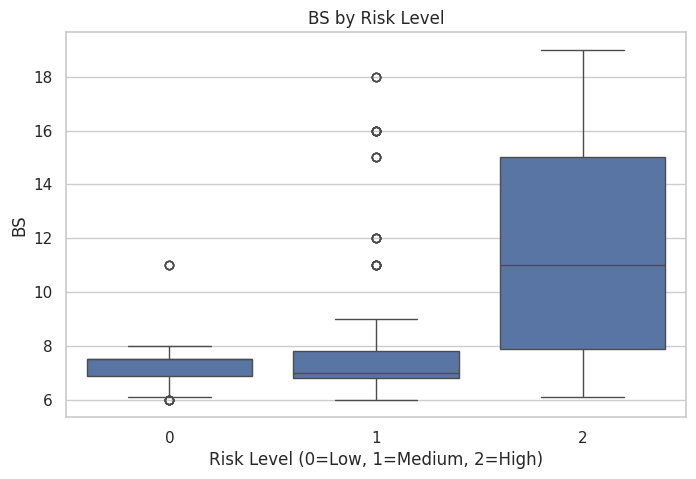

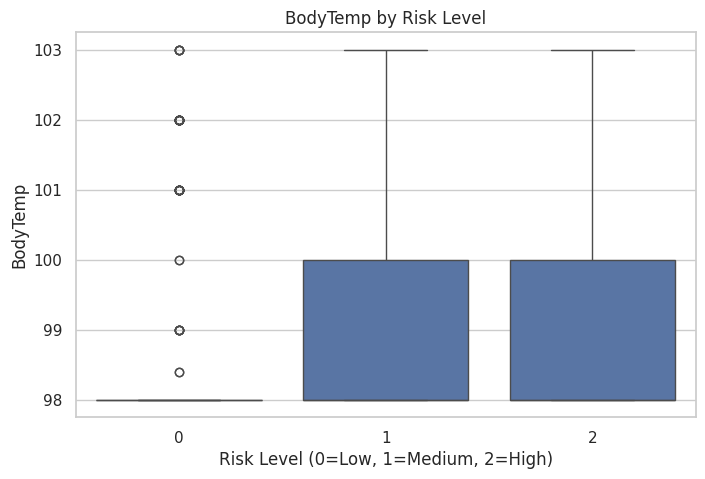

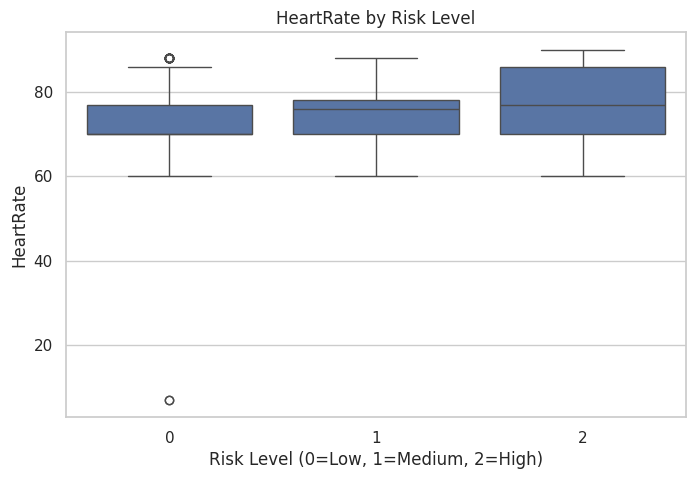

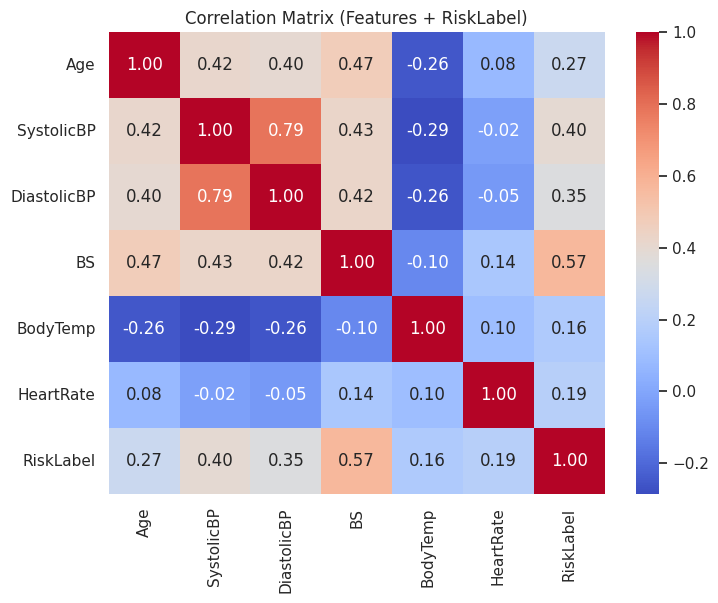

In [ ]:
# Features are standard vital signs from the dataset
feature_cols = ["Age", "SystolicBP", "DiastolicBP", "BS", "BodyTemp", "HeartRate"]
target_col = "RiskLabel"
class_names = ["Low", "Medium", "High"]

# 3.1 Risk level distribution
sns.countplot(data=df, x=target_col)
plt.title("Distribution of Maternal Risk Levels (0=Low, 1=Medium, 2=High)")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

# 3.2 Boxplots: how each vital sign varies across risk levels
for col in feature_cols:
    plt.figure()
    sns.boxplot(data=df, x=target_col, y=col)
    plt.title(f"{col} by Risk Level")
    plt.xlabel("Risk Level (0=Low, 1=Medium, 2=High)")
    plt.ylabel(col)
    plt.show()

# 3.3 Correlation matrix (features + target)
corr = df[feature_cols + [target_col]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Features + RiskLabel)")
plt.show()

Train/Test Split and 10 Fold Set Up

In [ ]:
X = df[feature_cols].copy()
y = df[target_col].copy()

# Hold-out test set gives an unbiased estimate of performance
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain label distribution (proportions):")
print(y_train.value_counts(normalize=True))

# 10-fold stratified CV provides robust metrics with limited data
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# Shared scoring dict used for all models
scoring = {
    "accuracy": "accuracy",
    "macro_f1": make_scorer(f1_score, average="macro"),
    "weighted_f1": make_scorer(f1_score, average="weighted"),
    "macro_recall": make_scorer(recall_score, average="macro"),
}

Train shape: (811, 6)
Test shape: (203, 6)

Train label distribution (proportions):
RiskLabel
0    0.400740
1    0.331689
2    0.267571
Name: proportion, dtype: float64


Rule-Based "Clinical" Baseline

=== Rule-based baseline performance on test set ===
Accuracy: 0.5960591133004927

Classification report (Rule-based):
              precision    recall  f1-score   support

         Low      0.573     0.778     0.660        81
      Medium      0.750     0.134     0.228        67
        High      0.605     0.891     0.721        55

    accuracy                          0.596       203
   macro avg      0.643     0.601     0.536       203
weighted avg      0.640     0.596     0.534       203



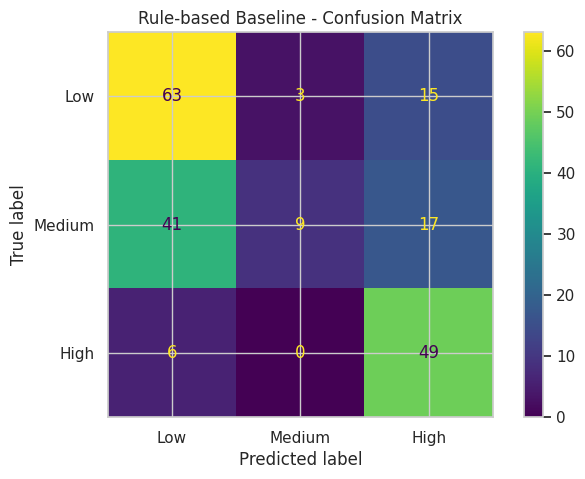

In [ ]:
def rule_based_risk(row: pd.Series) -> int:
    """
    Very simple heuristic baseline approximating manual triage:
    - High risk: clearly elevated blood pressure, blood sugar, or heart rate.
    - Medium risk: moderately raised blood pressure.
    - Low risk: otherwise.

    These thresholds are illustrative, not official guidelines. They are here to
    provide a ‘status quo’ baseline to compare machine learning models against.
    """
    sbp = row["SystolicBP"]
    dbp = row["DiastolicBP"]
    bs = row["BS"]
    hr = row["HeartRate"]

    # High risk (aggressive thresholds to minimise missed high-risk cases)
    if (sbp >= 140) or (dbp >= 90) or (bs >= 11) or (hr >= 110):
        return 2
    # Medium risk
    elif (sbp >= 130) or (dbp >= 85):
        return 1
    # Low risk
    else:
        return 0

# Apply baseline to hold-out test set
y_pred_rule = X_test.apply(rule_based_risk, axis=1)

print("=== Rule-based baseline performance on test set ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rule))
print("\nClassification report (Rule-based):")
print(classification_report(y_test, y_pred_rule, target_names=class_names, digits=3))

cm_rule = confusion_matrix(y_test, y_pred_rule)
ConfusionMatrixDisplay(cm_rule, display_labels=class_names).plot(values_format="d")
plt.title("Rule-based Baseline - Confusion Matrix")
plt.show()

Evaluation Utilities (CV + hold-out)

In [ ]:
def evaluate_cv(
    estimator,
    X: pd.DataFrame,
    y: pd.Series,
    cv,
    scoring: Dict[str, Any],
    label: str,
) -> Dict[str, float]:
    """
    Run 10-fold cross-validation for a given estimator and print average metrics.

    Parameters
    ----------
    estimator : sklearn estimator or Pipeline
    X, y      : training data
    cv        : cross-validation splitter
    scoring   : dict of scoring metrics
    label     : friendly name for logging

    Returns
    -------
    metrics_mean : dict of mean CV scores across folds
    """
    print(f"\n=== {label}: 10-fold cross-validation (train set) ===")
    cv_results = cross_validate(
        estimator,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )
    metrics_mean = {metric: cv_results[f"test_{metric}"].mean() for metric in scoring.keys()}
    for k, v in metrics_mean.items():
        print(f"{k}: {v:.3f}")
    return metrics_mean


def evaluate_holdout(
    estimator,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    title: str,
    class_names: list[str],
) -> Dict[str, float]:
    """
    Evaluate a trained estimator on the hold-out test set and plot confusion matrix.

    Returns a dict of key metrics used later for comparative analysis.
    """
    y_pred = estimator.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=class_names, digits=3)

    print(f"\n=== {title}: Hold-out test performance ===")
    print(f"Accuracy: {acc:.3f}\n")
    print(report)

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
    plt.title(f"{title} - Confusion Matrix")
    plt.show()

    # Extract useful metrics for comparison (especially high-risk recall)
    report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
    metrics = {
        "accuracy": acc,
        "macro_f1": report_dict["macro avg"]["f1-score"],
        "weighted_f1": report_dict["weighted avg"]["f1-score"],
        "high_recall": report_dict["High"]["recall"],
    }
    return metrics

Logistic Regression - Interpreterble baseline ML


=== Logistic Regression (base pipeline): 10-fold cross-validation (train set) ===
accuracy: 0.597
macro_f1: 0.600
weighted_f1: 0.595
macro_recall: 0.602


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Best Logistic Regression params: {'clf__C': 0.1}

=== Logistic Regression (tuned): Hold-out test performance ===
Accuracy: 0.645

              precision    recall  f1-score   support

         Low      0.671     0.679     0.675        81
      Medium      0.492     0.433     0.460        67
        High      0.758     0.855     0.803        55

    accuracy                          0.645       203
   macro avg      0.640     0.655     0.646       203
weighted avg      0.635     0.645     0.639       203



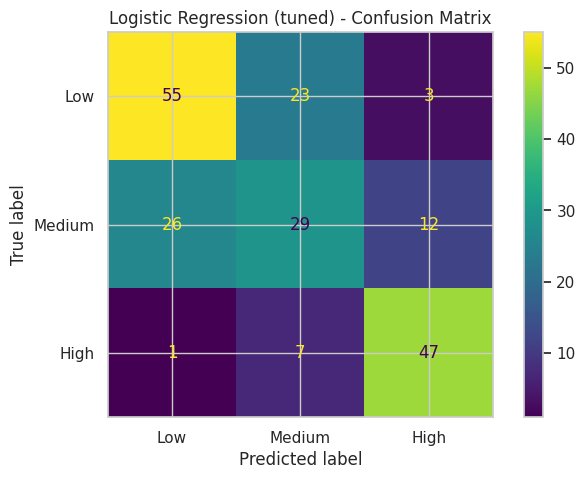


Logistic Regression coefficients (scaled features):


,Class 0 (Low),Class 1 (Medium),Class 2 (High)
Age,0.022878,0.005123,-0.028001
SystolicBP,-0.647881,0.248955,0.398926
DiastolicBP,0.018631,-0.355650,0.337020
BS,-0.763259,-0.215837,0.979096
BodyTemp,-0.544091,0.009675,0.534416
HeartRate,-0.204939,-0.018731,0.223670


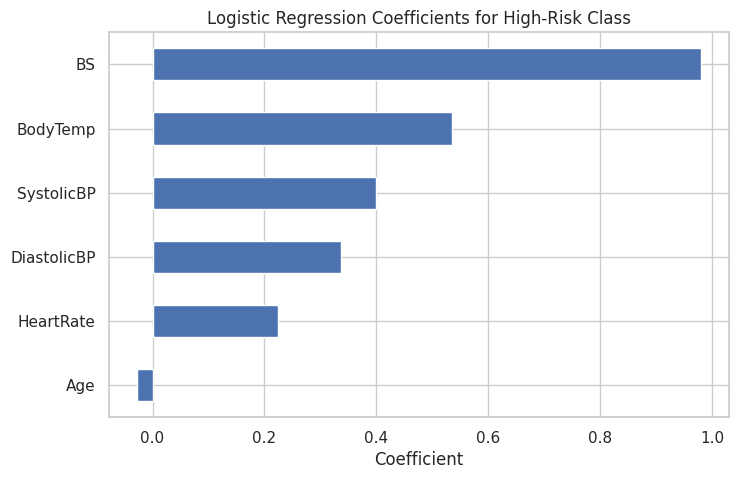

In [ ]:
# Pipeline combines scaling + logistic regression
log_reg_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "clf",
            LogisticRegression(
                multi_class="multinomial",
                solver="lbfgs",
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# Small hyperparameter grid: balances rigour and overfitting risk
log_reg_param_grid = {
    "clf__C": [0.1, 1.0, 10.0],
}

log_reg_grid = GridSearchCV(
    estimator=log_reg_pipeline,
    param_grid=log_reg_param_grid,
    scoring=make_scorer(f1_score, average="macro"),
    cv=cv,
    n_jobs=-1,
    refit=True,
)

# CV metrics for the base pipeline (no tuning)
log_reg_cv_metrics = evaluate_cv(
    log_reg_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    label="Logistic Regression (base pipeline)",
)

# Fit tuned model on full train set
log_reg_grid.fit(X_train, y_train)
print("\nBest Logistic Regression params:", log_reg_grid.best_params_)

# Evaluate tuned model on hold-out test set
metrics_lr = evaluate_holdout(
    log_reg_grid.best_estimator_,
    X_test,
    y_test,
    title="Logistic Regression (tuned)",
    class_names=class_names,
)

# Inspect coefficients for global interpretability
best_lr = log_reg_grid.best_estimator_
clf_lr = best_lr.named_steps["clf"]

coef_df = pd.DataFrame(
    clf_lr.coef_.T,
    index=feature_cols,
    columns=["Class 0 (Low)", "Class 1 (Medium)", "Class 2 (High)"],
)

print("\nLogistic Regression coefficients (scaled features):")
display(coef_df)

plt.figure(figsize=(8, 5))
coef_df["Class 2 (High)"].sort_values().plot(kind="barh")
plt.title("Logistic Regression Coefficients for High-Risk Class")
plt.xlabel("Coefficient")
plt.show()

Random Forest- Tree Ensemble


=== Random Forest (base): 10-fold cross-validation (train set) ===
accuracy: 0.842
macro_f1: 0.846
weighted_f1: 0.842
macro_recall: 0.849

Best Random Forest params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 400}

=== Random Forest (tuned): Hold-out test performance ===
Accuracy: 0.852

              precision    recall  f1-score   support

         Low      0.868     0.815     0.841        81
      Medium      0.806     0.806     0.806        67
        High      0.883     0.964     0.922        55

    accuracy                          0.852       203
   macro avg      0.853     0.861     0.856       203
weighted avg      0.852     0.852     0.851       203



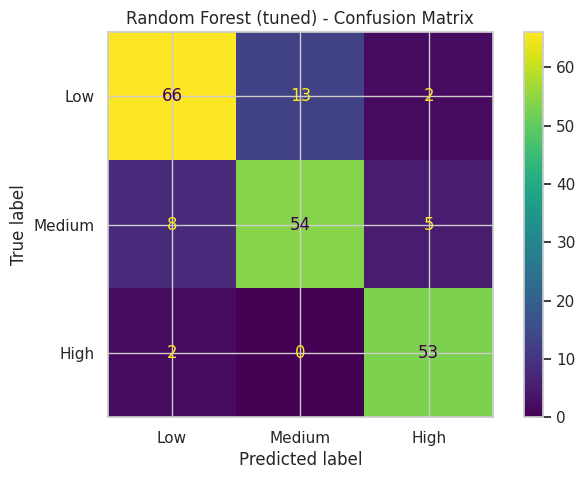

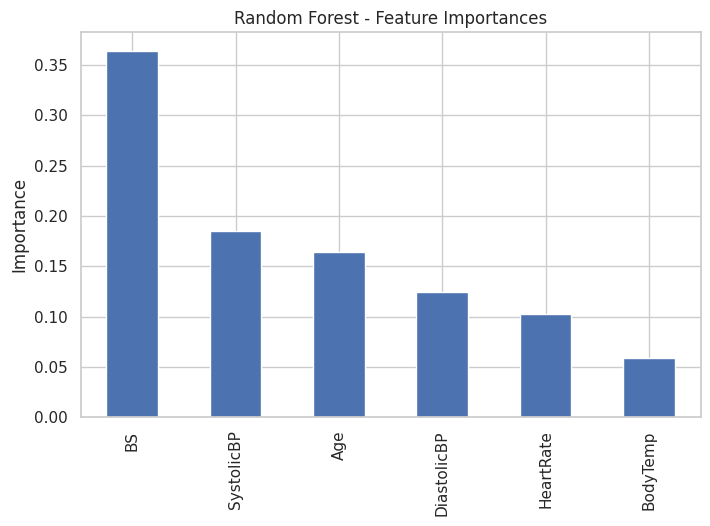

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# Modest grid for tuning – enough to search but not crazy
rf_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 6, 10],
    "max_features": ["sqrt", "log2"],
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    scoring=make_scorer(f1_score, average="macro"),
    cv=cv,
    n_jobs=-1,
    refit=True,
)

# CV metrics for base RF (no tuning)
rf_cv_metrics = evaluate_cv(
    rf,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    label="Random Forest (base)",
)

# Fit tuned RF on full train set
rf_grid.fit(X_train, y_train)
print("\nBest Random Forest params:", rf_grid.best_params_)

# Evaluate tuned RF on hold-out test set
metrics_rf = evaluate_holdout(
    rf_grid.best_estimator_,
    X_test,
    y_test,
    title="Random Forest (tuned)",
    class_names=class_names,
)

# Global feature importance from tuned RF
best_rf = rf_grid.best_estimator_
feat_imp = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure()
feat_imp.plot(kind="bar")
plt.title("Random Forest - Feature Importances")
plt.ylabel("Importance")
plt.show()

XGBoost- Gradient Boosting Ensemble


=== XGBoost (base): 10-fold cross-validation (train set) ===
accuracy: 0.804
macro_f1: 0.806
weighted_f1: 0.803
macro_recall: 0.805

Best XGBoost params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 400}

=== XGBoost (tuned): Hold-out test performance ===
Accuracy: 0.852

              precision    recall  f1-score   support

         Low      0.859     0.827     0.843        81
      Medium      0.815     0.791     0.803        67
        High      0.883     0.964     0.922        55

    accuracy                          0.852       203
   macro avg      0.853     0.861     0.856       203
weighted avg      0.851     0.852     0.851       203



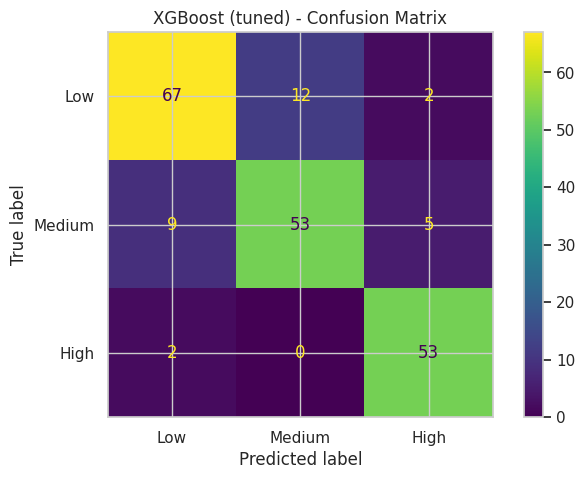

In [ ]:
xgb = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
)

xgb_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.03, 0.05, 0.1],
}

xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_param_grid,
    scoring=make_scorer(f1_score, average="macro"),
    cv=cv,
    n_jobs=-1,
    refit=True,
)

# CV metrics for base XGBoost
xgb_cv_metrics = evaluate_cv(
    estimator=xgb,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=scoring,
    label="XGBoost (base)",
)

# Fit tuned XGB on full train set
xgb_grid.fit(X_train, y_train)
print("\nBest XGBoost params:", xgb_grid.best_params_)

# Evaluate tuned XGB on hold-out test set
metrics_xgb = evaluate_holdout(
    xgb_grid.best_estimator_,
    X_test,
    y_test,
    title="XGBoost (tuned)",
    class_names=class_names,
)

Comparative Analysis Table

In [ ]:
# Metrics for rule-based baseline
rule_report = classification_report(
    y_test,
    y_pred_rule,
    target_names=class_names,
    output_dict=True,
)
rule_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_rule),
    "macro_f1": rule_report["macro avg"]["f1-score"],
    "weighted_f1": rule_report["weighted avg"]["f1-score"],
    "high_recall": rule_report["High"]["recall"],
}

metrics_summary = pd.DataFrame(
    [
        {"Model": "Rule-based", **rule_metrics},
        {"Model": "Logistic Regression (tuned)", **metrics_lr},
        {"Model": "Random Forest (tuned)", **metrics_rf},
        {"Model": "XGBoost (tuned)", **metrics_xgb},
    ]
)

display(
    metrics_summary
    .set_index("Model")
    .style.format("{:.3f}")
    .set_caption("Model Performance Comparison (Hold-out Test Set)")
)

,accuracy,macro_f1,weighted_f1,high_recall
Model,,,,
Rule-based,0.596,0.536,0.534,0.891
Logistic Regression (tuned),0.645,0.646,0.639,0.855
Random Forest (tuned),0.852,0.856,0.851,0.964
XGBoost (tuned),0.852,0.856,0.851,0.964


SHAP Explainability - Global and Local (Random Forest)

SHAP summary plot for High-risk class (2):


/tmp/ipython-input-549586697.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


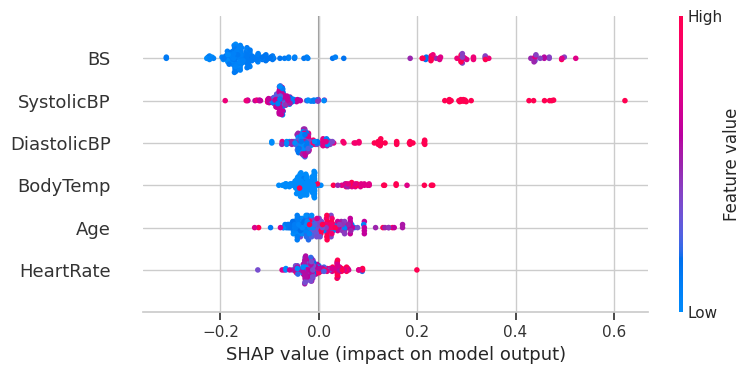

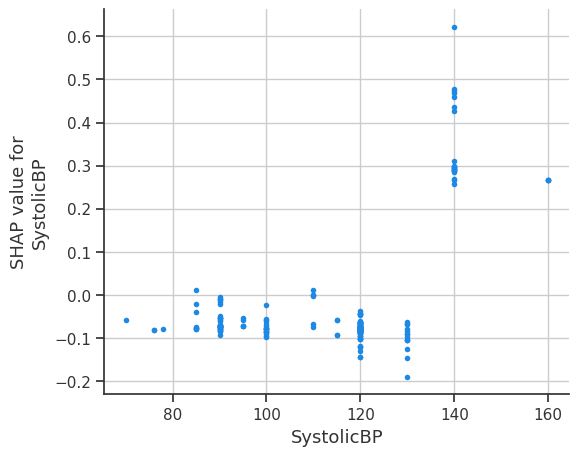

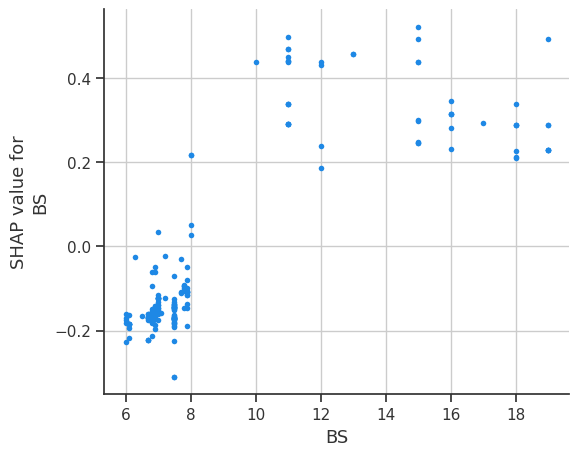


Using test index 6 as a high-risk case for local explanation.

Example patient's vital signs:


,274
Age,40.0
SystolicBP,120.0
DiastolicBP,95.0
BS,11.0
BodyTemp,98.0
HeartRate,80.0


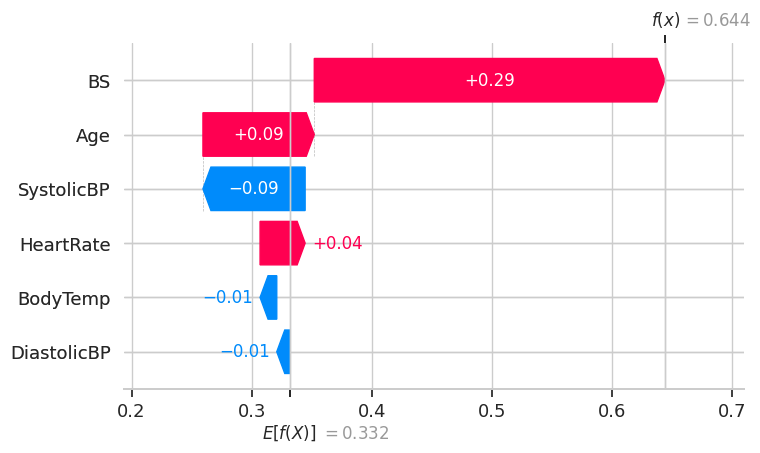

In [ ]:
best_rf = rf_grid.best_estimator_

shap.initjs()

# TreeExplainer is optimised for tree-based ensembles
rf_explainer = shap.TreeExplainer(best_rf)
X_test_for_shap = X_test.copy()

# For multiclass, shap_values is a list: one array per class
# Correction: shap_values for TreeExplainer is often a 3D array (samples, features, classes)
shap_values_rf = rf_explainer.shap_values(X_test_for_shap)

# 11.1 Global explanation: which features drive HIGH-RISK predictions?
print("SHAP summary plot for High-risk class (2):")
shap.summary_plot(
    shap_values_rf[:, :, 2],      # SHAP values for high-risk class (class index 2)
    X_test_for_shap,
    feature_names=feature_cols,
    show=True,
)

# 11.2 Dependence plots: non-linear effect of key features
shap.dependence_plot(
    "SystolicBP",
    shap_values_rf[:, :, 2],
    X_test_for_shap,
    interaction_index=None,
)

shap.dependence_plot(
    "BS",
    shap_values_rf[:, :, 2],
    X_test_for_shap,
    interaction_index=None,
)

# 11.3 Local explanation for an individual high-risk patient
high_risk_indices = np.where(y_test.values == 2)[0]

if len(high_risk_indices) == 0:
    print("No high-risk examples in test set; cannot produce local SHAP for class 2.")
else:
    example_idx = high_risk_indices[0]
    print(f"\nUsing test index {example_idx} as a high-risk case for local explanation.\n")

    example_features = X_test_for_shap.iloc[example_idx]
    print("Example patient's vital signs:")
    display(example_features)

    shap.plots._waterfall.waterfall_legacy(
        rf_explainer.expected_value[2],
        shap_values_rf[example_idx, :, 2], # Corrected: SHAP values for example_idx, all features, class 2
        feature_names=feature_cols,
    )

Simple What-If Analysis (Clinical Sensitivity)

In [ ]:
def predict_proba_for_patient(model, patient_row: pd.Series) -> np.ndarray:
    """
    Obtain risk probabilities (Low, Medium, High) for a single patient row.
    Designed for tree-based models that operate on the raw feature scale.
    """
    # Ensure the input to the model has feature names
    x = pd.DataFrame([patient_row[feature_cols].values], columns=feature_cols)
    return model.predict_proba(x)[0]

if len(high_risk_indices) > 0:
    example_idx = high_risk_indices[0]
    base_row = X_test.iloc[example_idx].copy()

    print("=== WHAT-IF ANALYSIS ON A HIGH-RISK PATIENT (Random Forest) ===\n")
    print("Original vital signs:")
    display(base_row)

    base_proba = predict_proba_for_patient(best_rf, base_row)
    print("Original predicted probabilities (Low, Medium, High):"), base_proba

    # Hypothetical improvement in BP and blood sugar (e.g. intervention)
    scenario_row = base_row.copy()
    scenario_row["SystolicBP"] = max(scenario_row["SystolicBP"] - 15, 90)
    scenario_row["DiastolicBP"] = max(scenario_row["DiastolicBP"] - 10, 50)
    scenario_row["BS"] = max(scenario_row["BS"] - 3, 3.0)

    print("\nModified vital signs (after hypothetical management):")
    display(scenario_row)

    scenario_proba = predict_proba_for_patient(best_rf, scenario_row)
    print("Modified predicted probabilities (Low, Medium, High):"), scenario_proba

    print("\nChange in High-risk probability:",
          float(scenario_proba[2] - base_proba[2]))
else:
    print("Skipping what-if analysis; no high-risk examples in test set.")

=== WHAT-IF ANALYSIS ON A HIGH-RISK PATIENT (Random Forest) ===

Original vital signs:


,274
Age,40.0
SystolicBP,120.0
DiastolicBP,95.0
BS,11.0
BodyTemp,98.0
HeartRate,80.0


Original predicted probabilities (Low, Medium, High):

Modified vital signs (after hypothetical management):


,274
Age,40.0
SystolicBP,105.0
DiastolicBP,85.0
BS,8.0
BodyTemp,98.0
HeartRate,80.0


Modified predicted probabilities (Low, Medium, High):

Change in High-risk probability: -0.24275406844654307


Deploment Style, Prediction Helper for UI/API

In [ ]:
def load_trained_model():
    """
    In a real deployment, this would load a persisted (pickled) model from disk
    or a model registry after validation and governance review.

    For this prototype, we simply return the tuned Random Forest instance.
    """
    return best_rf


def predict_maternal_risk(patient_features: Dict[str, float]) -> Dict[str, Any]:
    """
    Predict maternal health risk for a single patient.

    Parameters
    ----------
    patient_features : dict
        Keys must be: "Age", "SystolicBP", "DiastolicBP",
                      "BS", "BodyTemp", "HeartRate"

    Returns
    -------
    result : dict
        Contains the predicted risk class, label, and probabilities.
        This structure can be directly exposed via a REST API or UI layer.
    """
    model = load_trained_model()
    x = pd.DataFrame([patient_features], columns=feature_cols)
    proba = model.predict_proba(x)[0]
    pred_class = int(np.argmax(proba))

    return {
        "features": patient_features,
        "predicted_class": pred_class,
        "predicted_label": class_names[pred_class],
        "probabilities": {
            "Low": float(proba[0]),
            "Medium": float(proba[1]),
            "High": float(proba[2]),
        },
    }

# Example usage: simulating how a UI or API would call the model
example_patient = {
    "Age": 32,
    "SystolicBP": 145,
    "DiastolicBP": 95,
    "BS": 12.0,
    "BodyTemp": 98.6,
    "HeartRate": 115,
}

prediction = predict_maternal_risk(example_patient)
print("Deployment-style prediction example:")
print(prediction)

Deployment-style prediction example:
{'features': {'Age': 32, 'SystolicBP': 145, 'DiastolicBP': 95, 'BS': 12.0, 'BodyTemp': 98.6, 'HeartRate': 115}, 'predicted_class': 2, 'predicted_label': 'High', 'probabilities': {'Low': 0.0025, 'Medium': 0.025042878701700525, 'High': 0.9724571212982995}}
